# Loading sweep results.

## Preparing the notebook.

### Flags for autoreloading.

In [1]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Auto-reloading the notebook.

In [2]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

### Importing the libraries.

In [3]:
from collections import defaultdict
import os
import sys
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from tqdm import tqdm
import wandb
import yaml

from sc_exp_design.constants import DataFields
from sc_exp_design.models import FlowMatching

sys.path.insert(0, "../../../../data_analysis/subpopulation_distances")
from distances import compute_e_distance, compute_distance_fn

### Constants.

In [4]:
# data settings
PROTOCOL_REP = "protocol_concat"
CELL_STATE_REP = "X_channel_standardized+X_scatter_standardized"

# wandb settings
ENTITY = "haematopoiesis-cambridge"
PROJECT = f"sweep_cfm_{PROTOCOL_REP}_{CELL_STATE_REP}"

# paths
ANNOTATION_CONFIG_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/generative_modeling/conditional_flow_matching/config/annotation/default.yaml"
DISTS_DUMP_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/subpop_dists/preds"

### Utility functions.

In [5]:
def plot_marginals(X_real, X_gen=None, col_names=None, title=""):
    n_channels = X_real.shape[1]
    if X_gen is not None:
        assert X_gen.shape[1] == n_channels
    if col_names is not None:
        assert len(col_names) == n_channels

    fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
    fig.suptitle(f"{title}", fontsize=16)
    for i in range(n_channels):
        ax[i].grid(True)
        sns.kdeplot(X_real[:, i], ax=ax[i], color="green", label="real")
        if X_gen is not None:
            sns.kdeplot(X_gen[:, i], ax=ax[i], color="red", label="gen")
        ax[i].legend()
        if col_names is not None:
            ax[i].set_title(col_names[i])
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


## Prepare Wandb.

### Set-up the API and retrieve runs.

In [6]:
api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")
print(len(runs))

713


### Retrieving finished runs.

In [7]:
finished_runs = []
for run in runs:
    if run.state == "finished":
        finished_runs.append(run)
print(len(finished_runs))

703


### Retrieving history of runs.

In [8]:
summary_list = []
for run in finished_runs:
    data = run.summary
    flat_data = {
        **data,
        **data['_wandb'],
        **run.config["ood"],
        **{
            "dump_path": os.path.join(run.config["paths"]["dump_dir"], f"{run.name}_FlowMatching.pkl")
        }
    }
    df = pd.DataFrame([flat_data])
    df.index = [run.name]
    summary_list.append(df)
summary_df = pd.concat(summary_list, axis=0)
summary_df.head()

,3_condition_concat_energy_distance,3_condition_concat_maximum_mean_discrepancy,3_condition_concat_r_squared,3_condition_concat_sinkhorn_divergence,3_condition_concat_wasserstein_distance,_runtime,_step,_timestamp,_wandb,all_conditions_energy_distance,...,4_condition_concat_energy_distance,4_condition_concat_maximum_mean_discrepancy,4_condition_concat_r_squared,4_condition_concat_sinkhorn_divergence,4_condition_concat_wasserstein_distance,6_condition_concat_energy_distance,6_condition_concat_maximum_mean_discrepancy,6_condition_concat_r_squared,6_condition_concat_sinkhorn_divergence,6_condition_concat_wasserstein_distance
giddy-pine-1,1.922707,0.004348,0.852585,2.955430e-23,31.087829,2475.573211,10009,1.762506e+09,{'runtime': 2674},1.922707,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tough-field-1,19.889672,0.038679,-38.201797,5.465064e-44,39.918899,2338.588565,10009,1.762506e+09,{'runtime': 2549},19.889672,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lilac-violet-3,1.312338,0.006557,0.918651,3.644580e-33,17.530707,25685.392473,10009,1.762529e+09,{'runtime': 25949},1.312338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
electric-surf-4,2.155129,0.008693,0.854531,1.753024e-42,18.339963,5359.894143,10009,1.762509e+09,{'runtime': 5624},2.155129,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wild-cherry-5,2.623747,0.013976,0.814138,0.000000e+00,31.484522,3264.986508,10009,1.762507e+09,{'runtime': 3521},2.623747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Retrieving only columns of interest.

In [9]:
results_df = summary_df.loc[:, [
    "all_conditions_energy_distance",
    "all_conditions_maximum_mean_discrepancy",
    "all_conditions_r_squared",
    "all_conditions_wasserstein_distance",
    "obs_column",
    "unique_value_ids",
    "dump_path",
]]
results_df.head()

,all_conditions_energy_distance,all_conditions_maximum_mean_discrepancy,all_conditions_r_squared,all_conditions_wasserstein_distance,obs_column,unique_value_ids,dump_path
giddy-pine-1,1.922707,0.004348,0.852585,31.087829,tpo_[ng_ml],3,/lustre/groups/ml01/workspace/lorenzo.consoli/...
tough-field-1,19.889672,0.038679,-38.201797,39.918899,tpo_[ng_ml],3,/lustre/groups/ml01/workspace/lorenzo.consoli/...
lilac-violet-3,1.312338,0.006557,0.918651,17.530707,tpo_[ng_ml],3,/lustre/groups/ml01/workspace/lorenzo.consoli/...
electric-surf-4,2.155129,0.008693,0.854531,18.339963,tpo_[ng_ml],3,/lustre/groups/ml01/workspace/lorenzo.consoli/...
wild-cherry-5,2.623747,0.013976,0.814138,31.484522,tpo_[ng_ml],3,/lustre/groups/ml01/workspace/lorenzo.consoli/...


### Grouping results by ood column and split.

In [10]:
split2results = {}
for group_id, group_idxs in results_df.groupby(by=["obs_column", "unique_value_ids"]).groups.items():
    print(f"{group_id} -> {len(group_idxs)}")
    split2results[group_id] = results_df.loc[group_idxs]
print(len(split2results), list(split2results.keys()))

('protocol_id', 0) -> 47
('protocol_id', 1) -> 76
('protocol_id', 6) -> 85
('tpo_[ng_ml]', 0) -> 40
('tpo_[ng_ml]', 1) -> 81
('tpo_[ng_ml]', 2) -> 31
('tpo_[ng_ml]', 3) -> 61
('tpo_[ng_ml]', 4) -> 78
('um171_[nm]', 0) -> 88
('um171_[nm]', 1) -> 36
('um171_[nm]', 2) -> 80
11 [('protocol_id', 0), ('protocol_id', 1), ('protocol_id', 6), ('tpo_[ng_ml]', 0), ('tpo_[ng_ml]', 1), ('tpo_[ng_ml]', 2), ('tpo_[ng_ml]', 3), ('tpo_[ng_ml]', 4), ('um171_[nm]', 0), ('um171_[nm]', 1), ('um171_[nm]', 2)]


### 

### Scatter plot of metrics against each other.

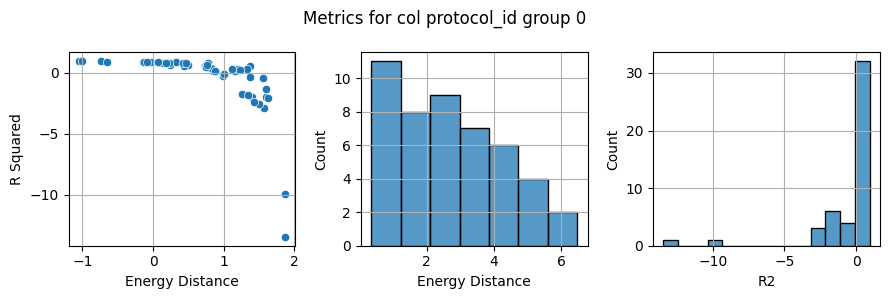

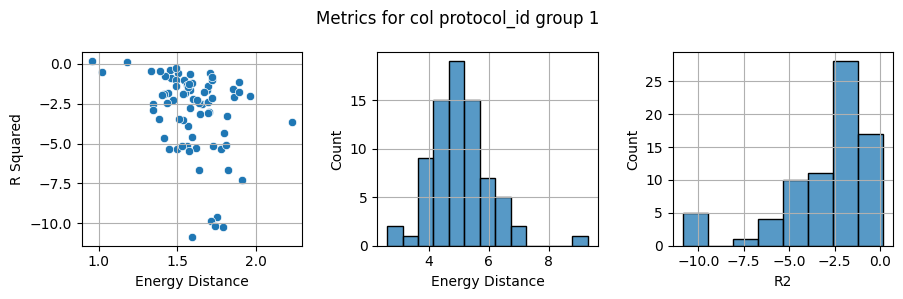

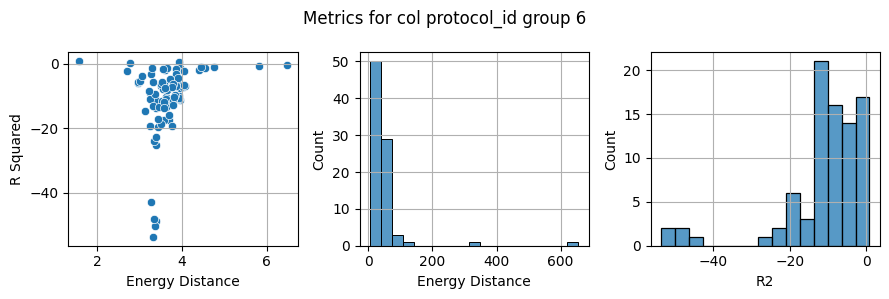

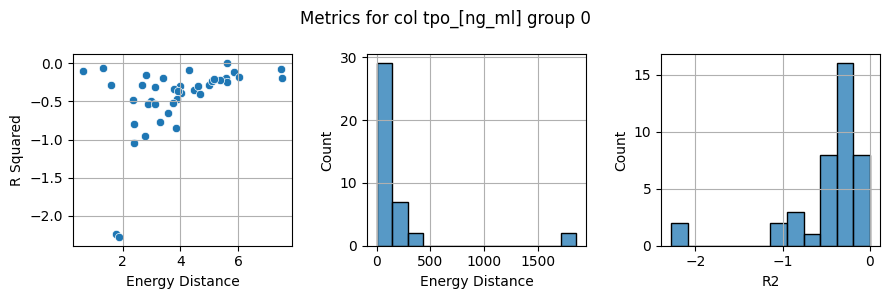

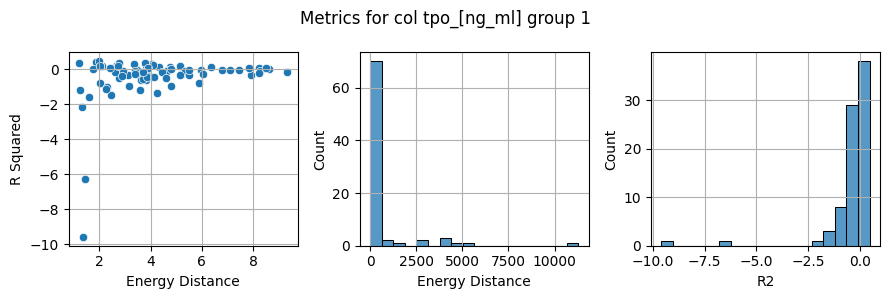

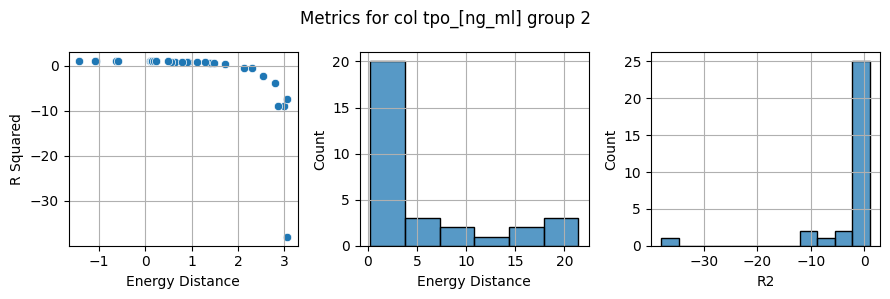

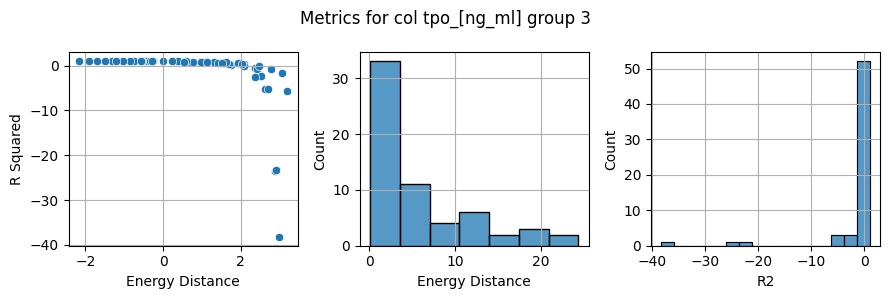

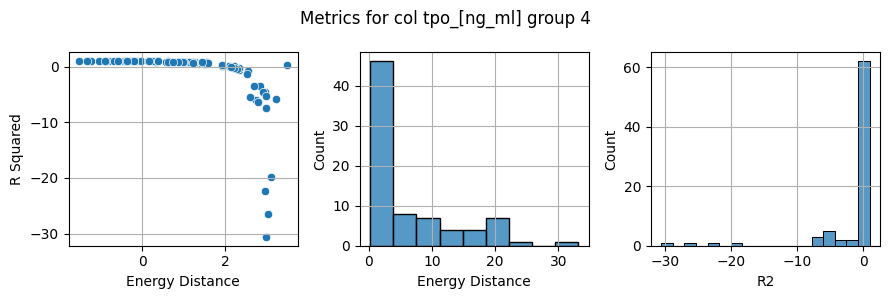

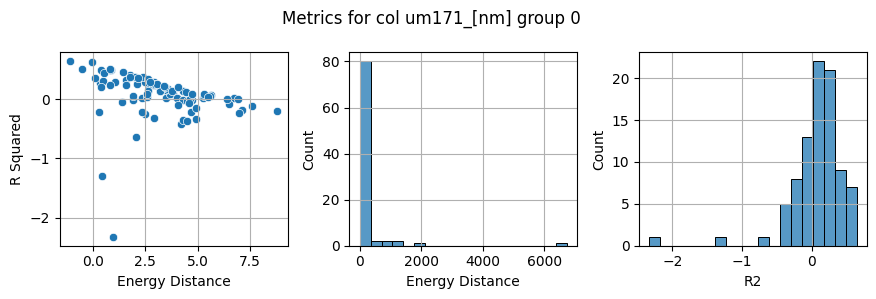

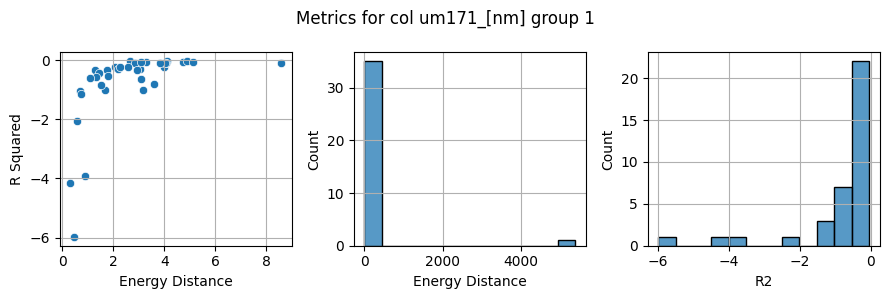

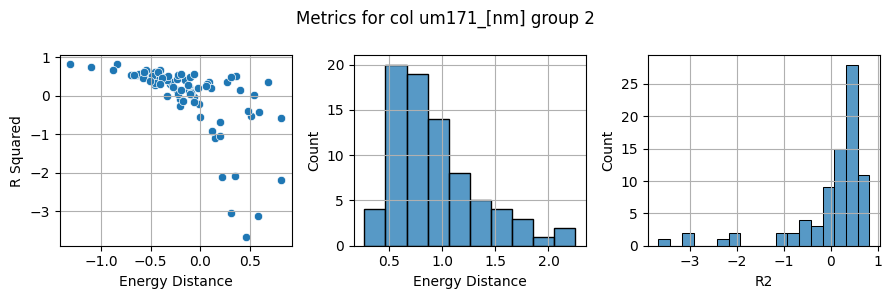

In [11]:
use_log_e_dist = True
for group_id, group_df in split2results.items():
    fig, ax = plt.subplots(1, 3, figsize=(9, 3))
    fig.suptitle(f"Metrics for col {group_id[0]} group {group_id[1]}")
    # scatter e dist r2
    if use_log_e_dist:
        group_df["log_e_dist"] = np.log(group_df["all_conditions_energy_distance"])
        sns.scatterplot(group_df, x="log_e_dist", y="all_conditions_r_squared", ax=ax[0])
    else:
        sns.scatterplot(group_df, x="all_conditions_energy_distance", y="all_conditions_r_squared", ax=ax[0])
    ax[0].set_xlabel("Energy Distance")
    ax[0].set_ylabel("R Squared")
    ax[0].grid(True)
    # hist e dist
    sns.histplot(group_df, x="all_conditions_energy_distance", ax=ax[1])
    ax[1].set_xlabel("Energy Distance")
    ax[1].grid(True)
    # hist r2
    sns.histplot(group_df, x="all_conditions_r_squared", ax=ax[2])
    ax[2].set_xlabel("R2")
    ax[2].grid(True)
    fig.tight_layout()
    fig.show()

### Retrieving best run id and metrics for each run.

In [12]:
criterion = "all_conditions_energy_distance"
index = []
ood2bestcfg = defaultdict(list)
for group_id, group_df in split2results.items():
    best_run_idx = np.argmin(group_df[criterion].values)
    best_model_path = group_df.iloc[best_run_idx]["dump_path"]
    best_criterion = group_df.iloc[best_run_idx][criterion]
    best_run_name = group_df.index[best_run_idx]
    ood2bestcfg["model_path"].append(best_model_path)
    ood2bestcfg["run_name"].append(best_run_name)
    ood2bestcfg["criterion"].append(best_criterion)
    index.append(group_id)
best_results_df = pd.DataFrame(ood2bestcfg)
best_results_df.index = pd.MultiIndex.from_tuples(index, names=["ood_col", "split"])
best_results_df

model_path  \
ood_col     split                                                      
protocol_id 0      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            1      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            6      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
tpo_[ng_ml] 0      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            1      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            2      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            3      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            4      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
um171_[nm]  0      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            1      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
            2      /lustre/groups/ml01/workspace/lorenzo.consoli/...   

                               run_name  criterion  
ood_col     split                                   
protocol_id 0       glamorous-paper-629   0.349477  
            1          iconic-smoke-502   2.602088  
            6       feasible-valley-669   4.787044  
tpo_[ng_ml] 0         winter-puddle-101   1.846813  
            1             hardy-sea-133   3.351141  
            2           noble-energy-33   0.239167  
            3            dulcet-dawn-85   0.115160  
            4          young-dragon-160   0.218788  
um171_[nm]  0         hopeful-water-364   0.333824  
            1       summer-elevator-441   1.371005  
            2      dainty-butterfly-425   0.270564

### Slicing for target value.

In [13]:
# defining target splits
ood_col = "tpo_[ng_ml]"
ood_val = 3

# defining masks
col_mask = best_results_df.index.map(lambda e: e[0] == ood_col)
val_mask = best_results_df.index.map(lambda e: e[1] == ood_val)
mask = (col_mask & val_mask)

# slicing df
tgt_res_df = best_results_df[mask]
tgt_res_df

,,model_path,run_name,criterion
ood_col,split,,,
tpo_[ng_ml],3,/lustre/groups/ml01/workspace/lorenzo.consoli/...,dulcet-dawn-85,0.11516


## Predicting with the model.

### Grouping by OOD column loading best model per split.

In [14]:
ood2model = {}
for row in tgt_res_df.iterrows():
    group_id, (path, run_name, criterion) = row
    print(f"Loading model for {group_id} from {best_model_path}")
    ood2model[group_id] = FlowMatching.load(best_model_path)


Loading model for ('tpo_[ng_ml]', 3) from /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-07_13-00-10/dainty-butterfly-425_FlowMatching.pkl


### Generating cells under each condition.

In [15]:
# sampling configuration
# n_samples = 30_000
n_samples = 3_000
n_time_steps = 100
solver_kwargs = {"method": "euler"}

# defining number of target cells to subsample
n_train_cells = 70_000
n_val_cells = 30_000

# dictionary to store the predictions
ood2preds = {}
ood2adatas = {}

# iterating over the splits
for group_id, model in ood2model.items():
    # retrieving data
    train_data = model.train_data
    val_data = next(iter(model.validation_data.values()))
    train_adata = train_data.adata
    val_adata = val_data.adata
    print(f"{group_id} N cells -> {len(train_data)=}, {len(val_data)=}")

    # retrieving condition identifier (only one element for condition concat)
    cond_id = next(iter(train_data.data.perturbation_covariates))

    # retrieving unique values for validation data
    ood_conds = np.unique(val_data.perturbation_data[cond_id], axis=0)
    n_ood_conds = ood_conds.shape[0]
    print(f"{group_id} N ood conds -> {n_ood_conds=}")

    # generating cell with the model
    model = ood2model[group_id]
    x_preds = model.predict(
        {
            DataFields.PERTURBATION_DATA: {
                cond_id: torch.from_numpy(ood_conds).float().to(model.device)
            }
        },
        num_samples=n_samples,
        num_time_steps=n_time_steps,
        solver_kwargs=solver_kwargs,
    ).detach().cpu().numpy()

    # storing the results
    ood2preds[group_id] = {
        "X": x_preds,
        "cond": ood_conds
    }
    ood2adatas[group_id] = {
        "train": sc.pp.sample(train_adata, n=n_train_cells, copy=True),
        "val": sc.pp.sample(val_adata, n=n_val_cells, copy=True)
    }
    del train_adata, val_adata


('tpo_[ng_ml]', 3) N cells -> len(train_data)=80969704, len(val_data)=12305750
('tpo_[ng_ml]', 3) N ood conds -> n_ood_conds=8


### Reading the file for the annotation config.

In [16]:
# reading file
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotations_dict = yaml.safe_load(fb)

# retrieving number of scatter features
scatter_columns = annotations_dict["scatter_columns"]
n_scatter_feats = len(scatter_columns)
print(f"{n_scatter_feats=}")

n_scatter_feats=6


### Concatenating real and generated cells in one single `anndata`.

In [17]:
# retrieving perturbation representation
perturbation_reps = next(iter(model.data_manager.perturbation_reps))
perturbation_obs_key = "protocol_id"

# defining dictionary to store results
ood2adatas_concat = {}

# iterating over the predictions
for group_id, adatas in ood2adatas.items():
    # parsing adatas dictionary
    train_adata = adatas["train"]
    val_adata = adatas["val"]

    # parsing predictions
    X = ood2preds[group_id]["X"]
    conds = ood2preds[group_id]["cond"]

    # dictionary to store the results
    group_adatas = {}

    # iterating over each unique condition
    for idx in tqdm(range(conds.shape[0])):

        # slicing for current condition
        x_preds = X[:, idx, :]

        # concatenating with predictions
        X_channel = np.concatenate(
            (
                train_adata.obsm[CELL_STATE_REP][:, :-n_scatter_feats],
                val_adata.obsm[CELL_STATE_REP][:, :-n_scatter_feats],
                x_preds[:, :-n_scatter_feats],
            ), axis=0
        )
        X_scatter = np.concatenate(
            (
                train_adata.obsm[CELL_STATE_REP][:, -n_scatter_feats:],
                val_adata.obsm[CELL_STATE_REP][:, -n_scatter_feats:],
                x_preds[:, -n_scatter_feats:],
            ), axis=0
        )

        # handling conditions
        conditions = np.concatenate(
            (
                train_adata.obsm[perturbation_reps],
                val_adata.obsm[perturbation_reps],
                np.repeat(conds[idx][None], n_samples, axis=0)
            )
        )
        unique_perts = np.unique(conditions, axis=0)
        perts_id = np.apply_along_axis(
            lambda e: np.where(
                np.all(
                    unique_perts == e, axis=-1
                ))[0].item(),
            -1,
            conditions
        ).tolist()

        # retrieving the mask for current ood cond
        val_cond_mask = np.all(val_adata.obsm[perturbation_reps] == conds[idx], axis=-1)

        # preparing the annotations
        obs = pd.DataFrame(
            {
                "dataset_type": [
                    "in-distribution" for _ in range(n_train_cells)
                ] + [
                    "ood" for _ in range(n_val_cells)
                ] + [
                    "generated" for _ in range(n_samples)
                ],
                "is_generated": [
                    False for _ in range(n_train_cells)
                ] + [
                    False for _ in range(n_val_cells)
                ] + [
                    True for _ in range(n_samples)
                ],
                "is_true_ood": [
                    False for _ in range(n_train_cells)
                ] + [
                    True for _ in range(n_val_cells)
                ] + [
                    False for _ in range(n_samples)
                ],
                "is_true_cond": [
                    False for _ in range(n_train_cells)
                ] + val_cond_mask.tolist() + [
                    False for _ in range(n_samples)
                ],
                perturbation_obs_key: perts_id
            }
        )
        uns = {
            "cond_id": cond_id,
            "cond_val": conds
        }
        obsm = {
            "X_scatter": X_scatter,
            perturbation_reps: conditions
        }

        # creating adata
        pred_adata_group = sc.AnnData(
            X=X_channel,
            obs=obs,
            uns=uns,
            obsm=obsm
        )

        # computing pcs, neighbors, umap
        sc.pp.pca(pred_adata_group)
        sc.pp.neighbors(pred_adata_group)
        sc.tl.umap(pred_adata_group)

        # storing the results
        group_adatas[idx] = pred_adata_group
    ood2adatas_concat[group_id] = group_adatas


  0%|          | 0/8 [00:00<?, ?it/s]/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
 12%|█▎        | 1/8 [01:32<10:46, 92.37s/it]/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
 25%|██▌       | 2/8 [02:25<06:56, 69.38s/it]/home/icb/lorenzo.consoli/miniconda3/envs

### Visualizing the predictions.

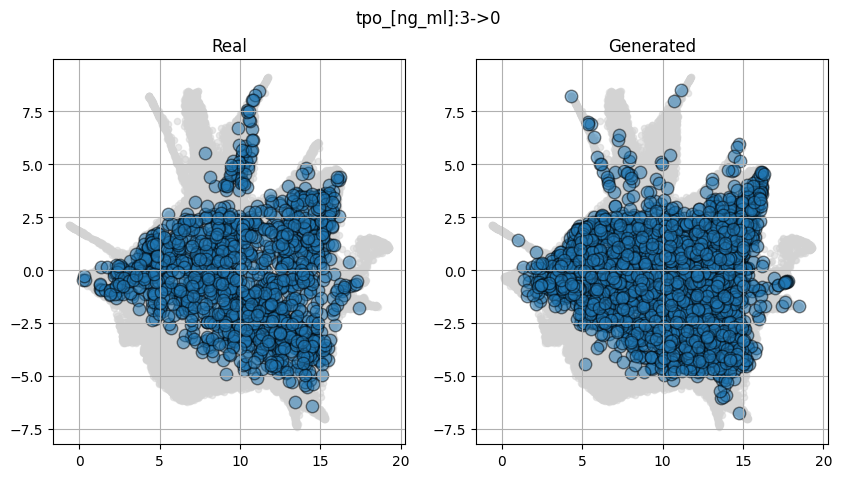

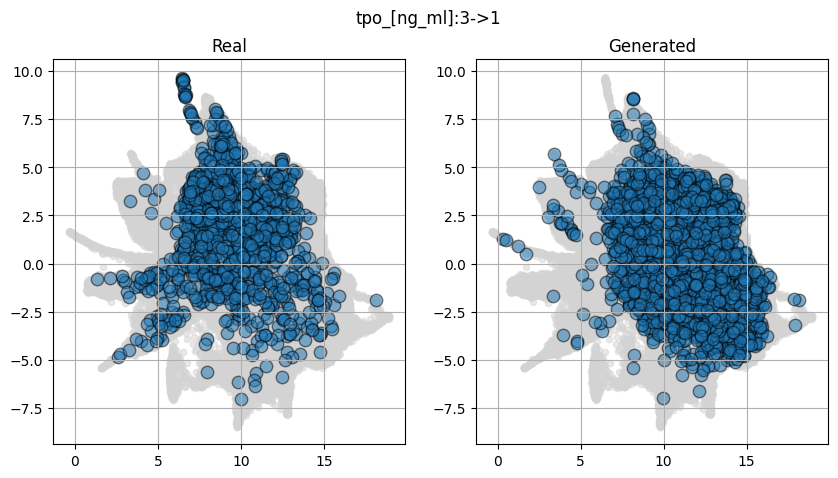

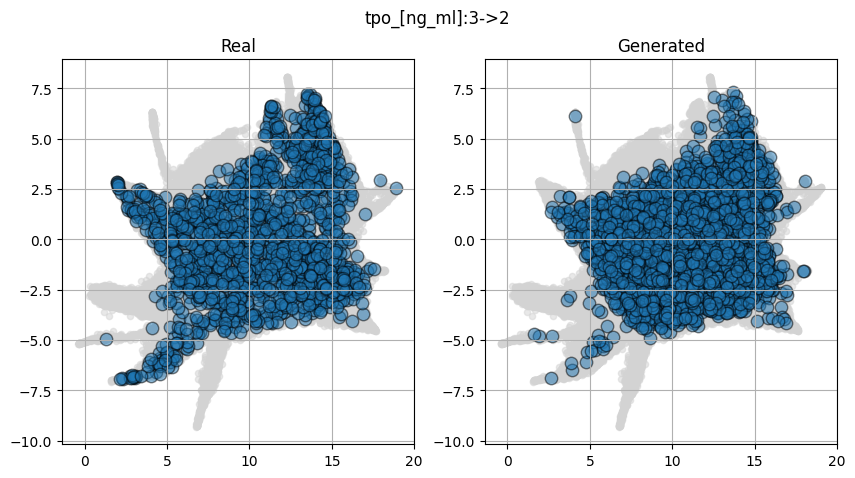

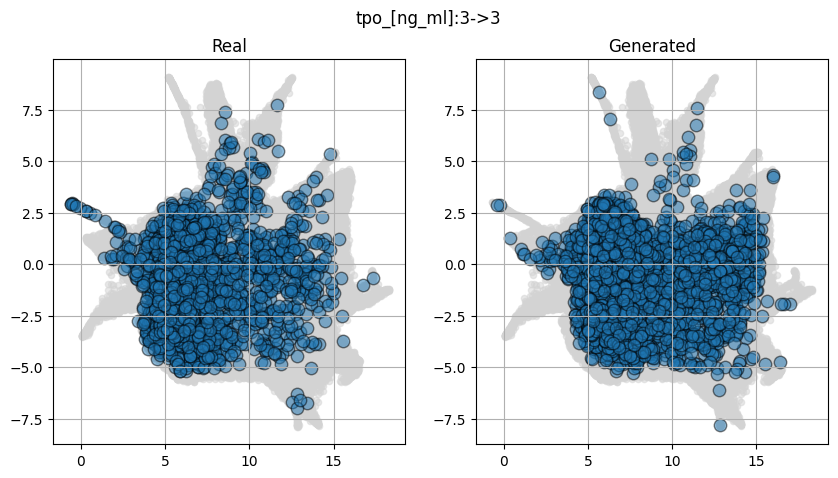

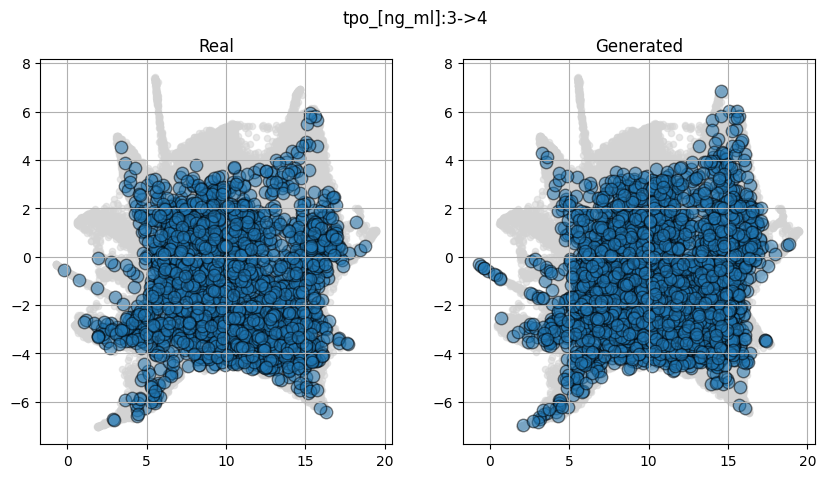

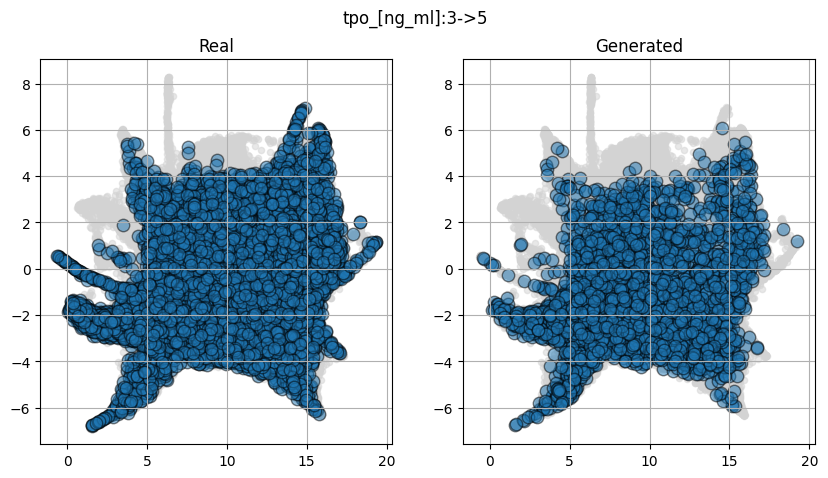

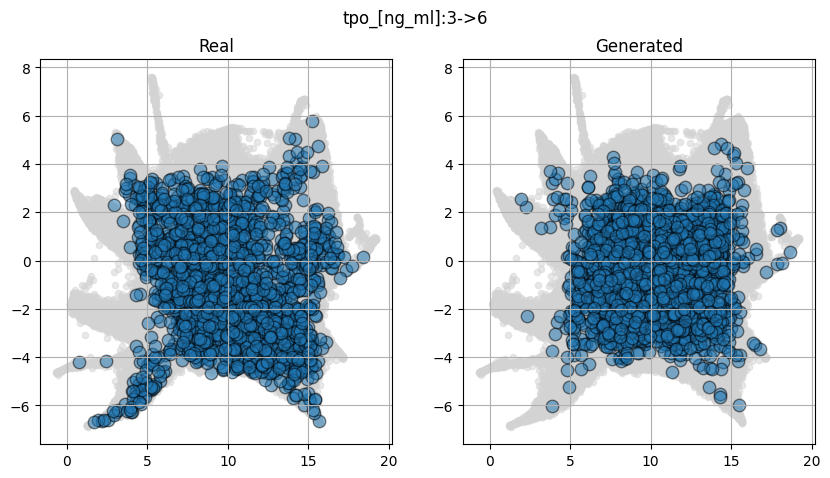

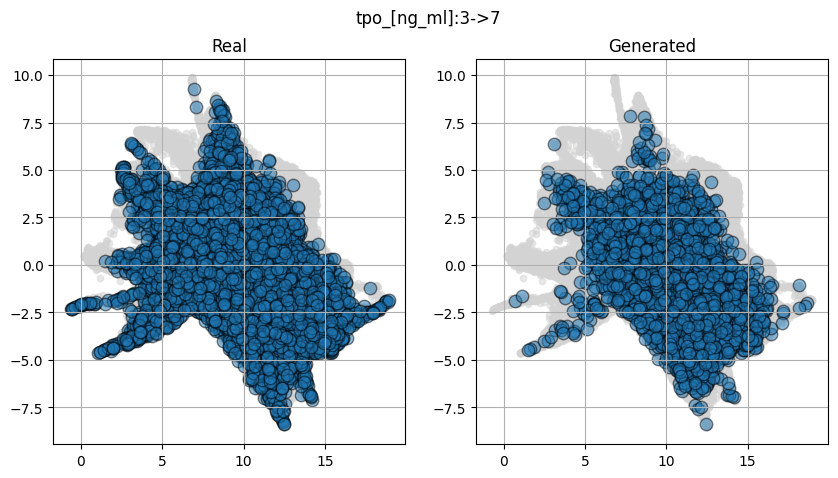

In [18]:
for group_id, pred_adata_group in ood2adatas_concat.items():
    for cond_id, pred_adata in pred_adata_group.items():
        # retrieving coordinates
        umap_coords = pred_adata.obsm["X_umap"]

        # defining figure
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"{group_id[0]}:{group_id[1]}->{cond_id}")

        # plot background
        ax[0].scatter(
            umap_coords[:, 0],
            umap_coords[:, 1],
            c='lightgrey',  # background cells
            s=20,           # smaller size
            alpha=0.5
        )
        ax[1].scatter(
            umap_coords[:, 0],
            umap_coords[:, 1],
            c='lightgrey',  # background cells
            s=20,           # smaller size
            alpha=0.5
        )

        # plot real and generated cells
        mask = pred_adata.obs["is_true_cond"]  
        ax[0].scatter(
            umap_coords[mask, 0],
            umap_coords[mask, 1],
            alpha=0.5,
            s=80,
            edgecolor='k',
        )
        ax[0].set_title("Real")
        ax[0].grid(1)
        mask = pred_adata.obs["is_generated"]  
        ax[1].scatter(
            umap_coords[mask, 0],
            umap_coords[mask, 1],
            alpha=0.5,
            s=80,
            edgecolor='k',
        )
        ax[1].set_title("Generated")
        ax[1].grid(1)
        fig.show()

### Plotting marginals.

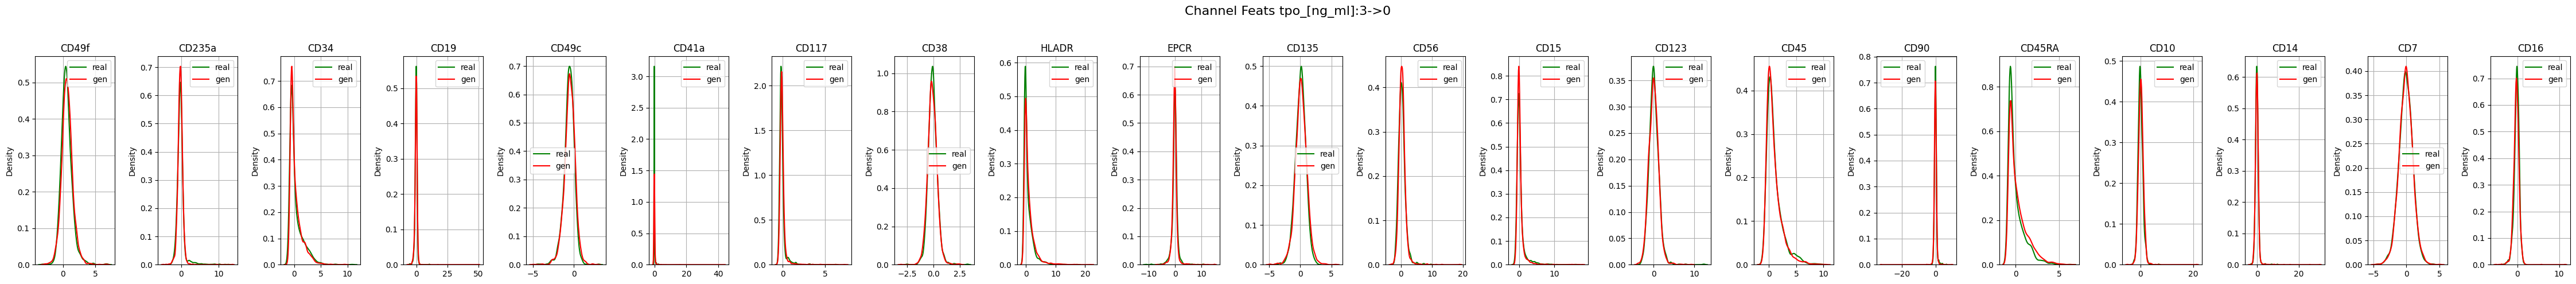

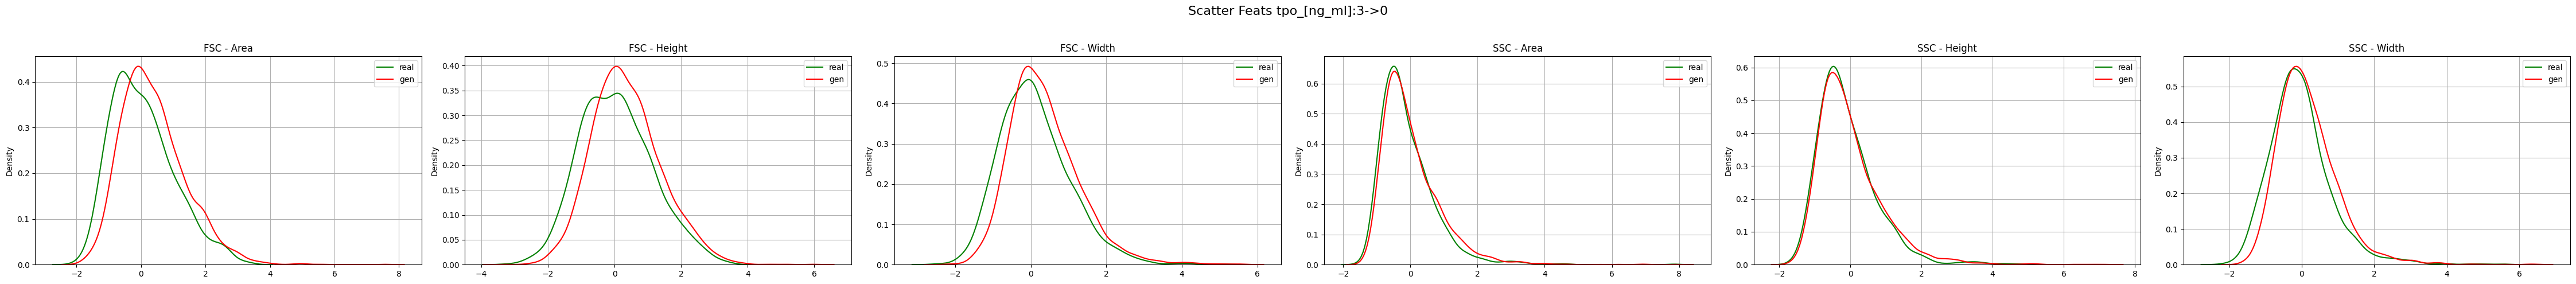

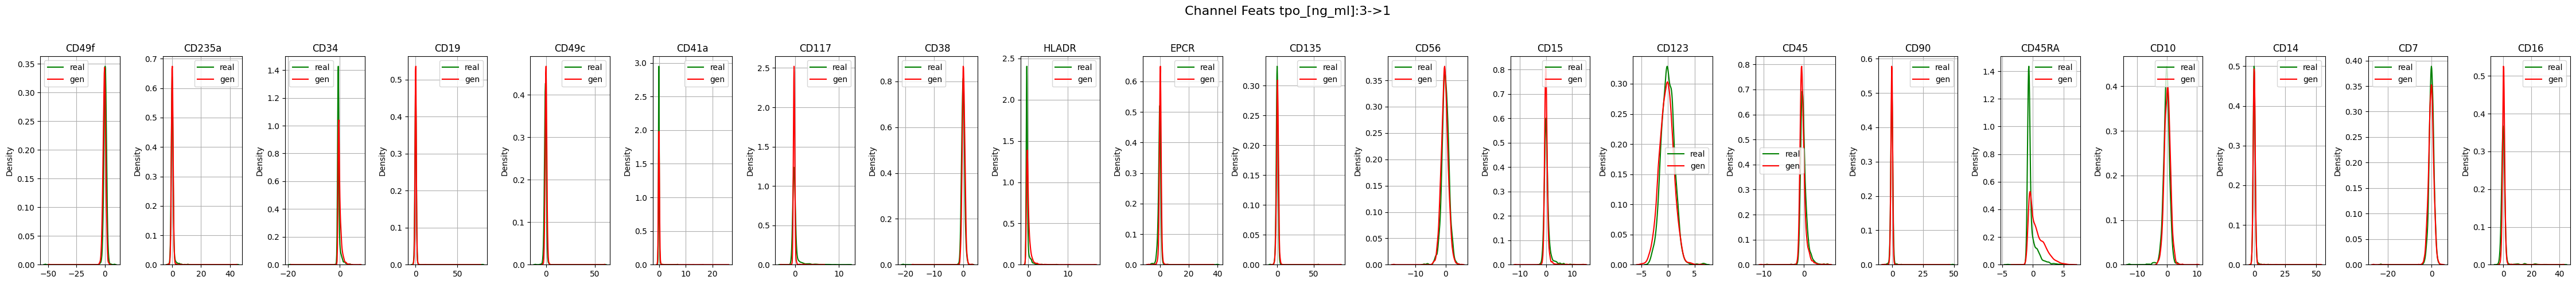

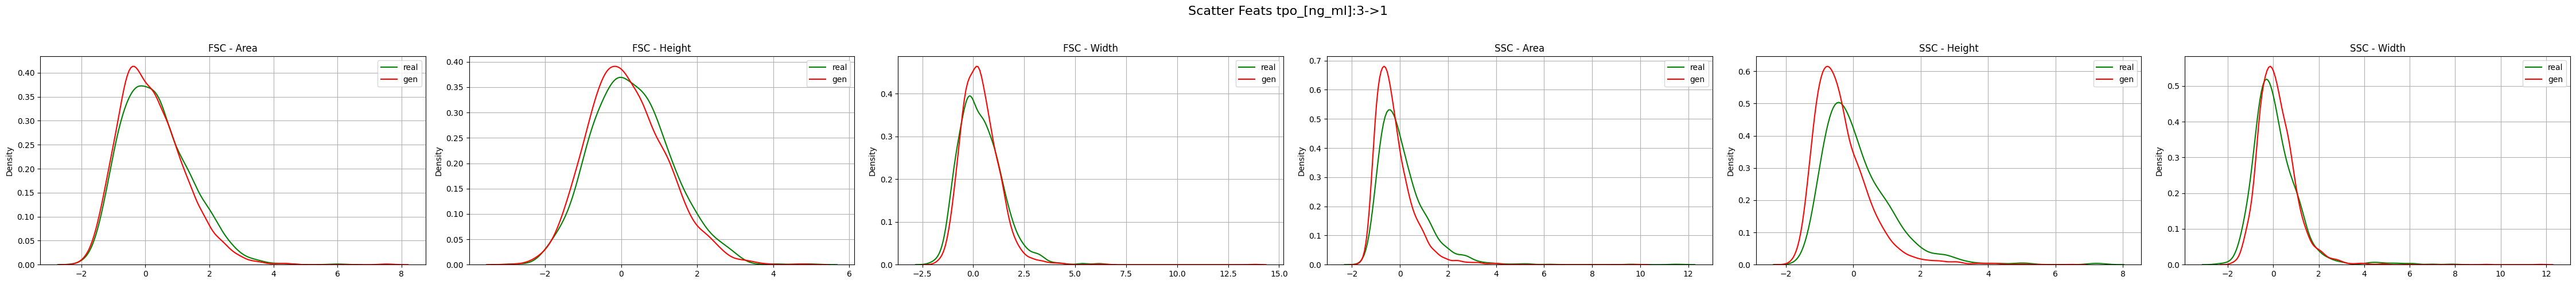

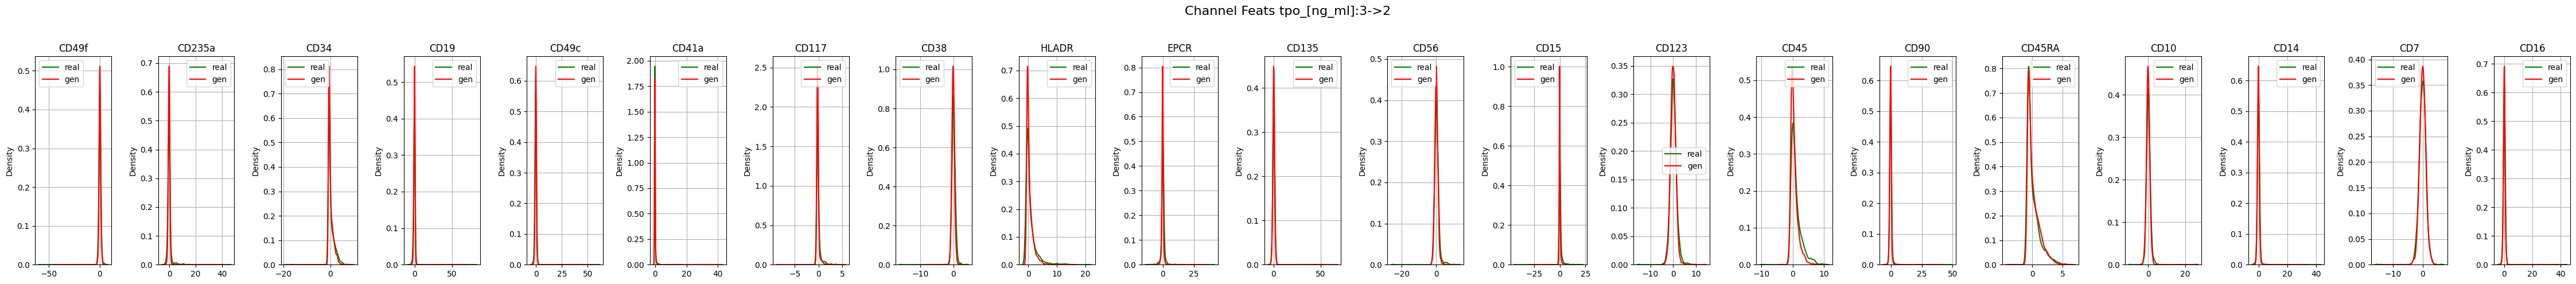

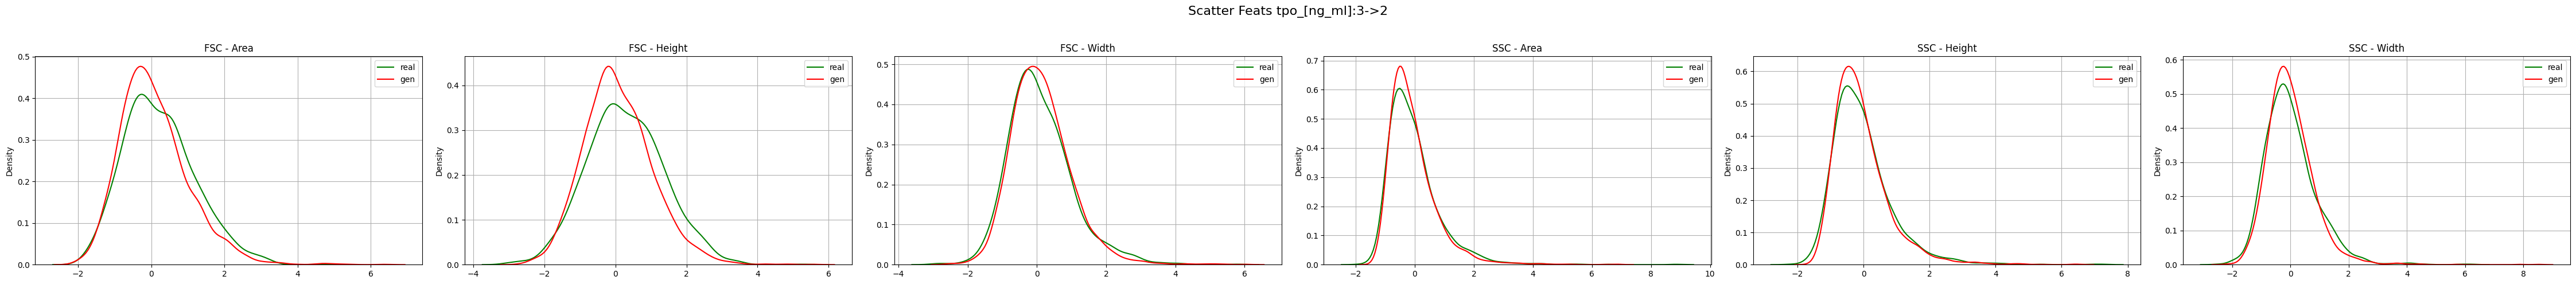

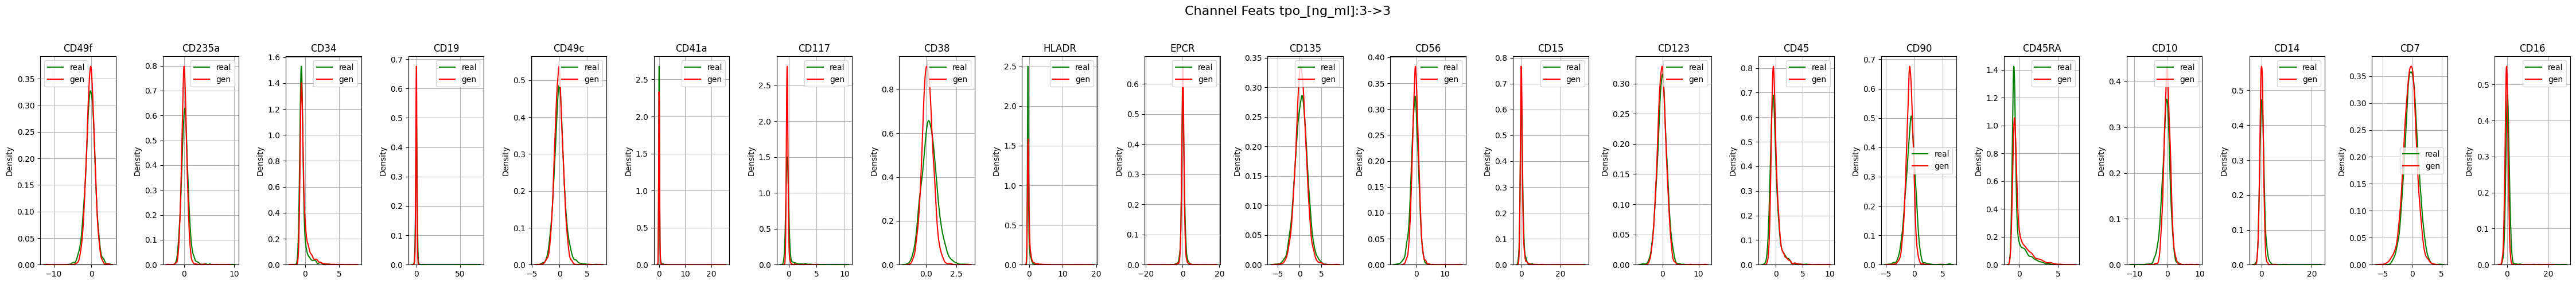

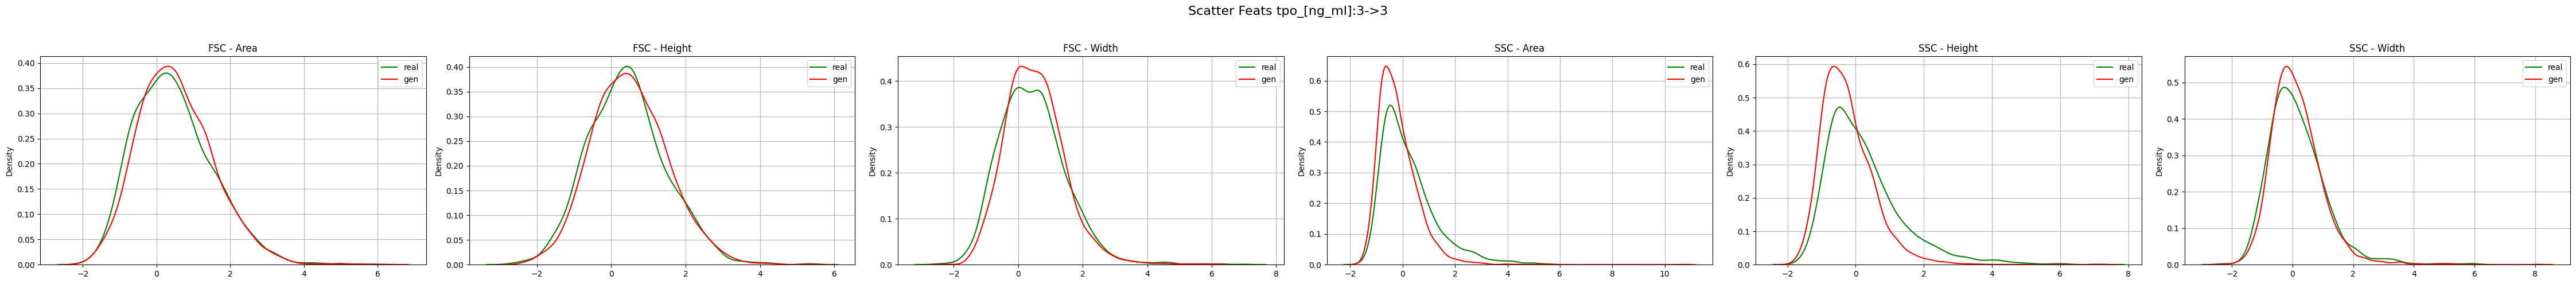

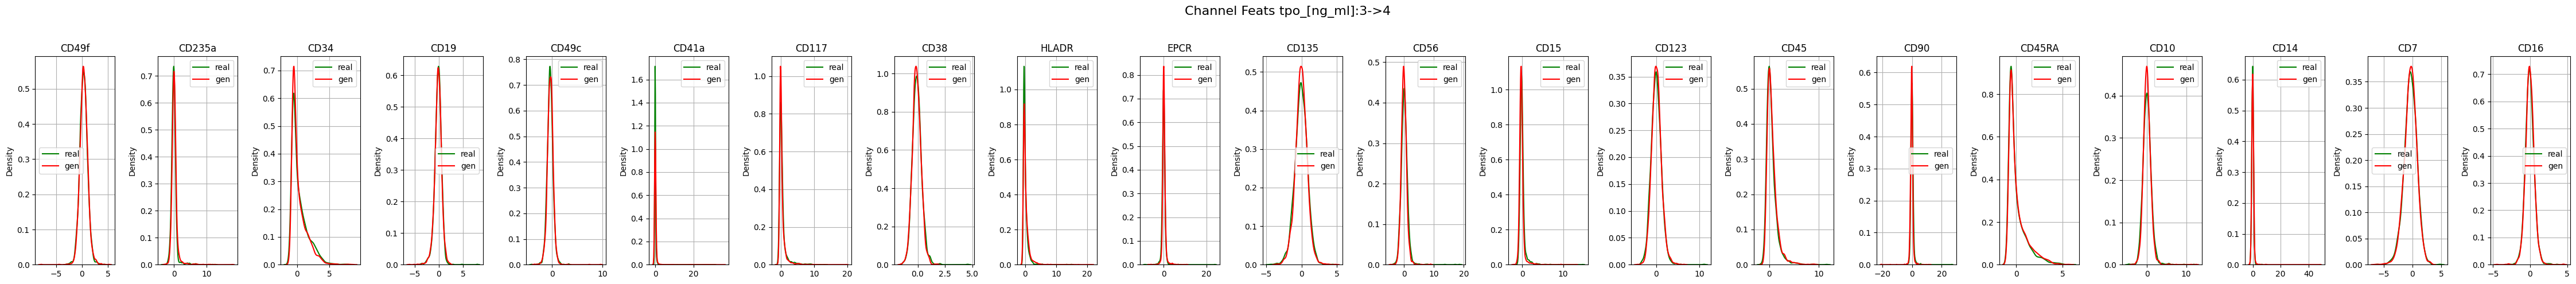

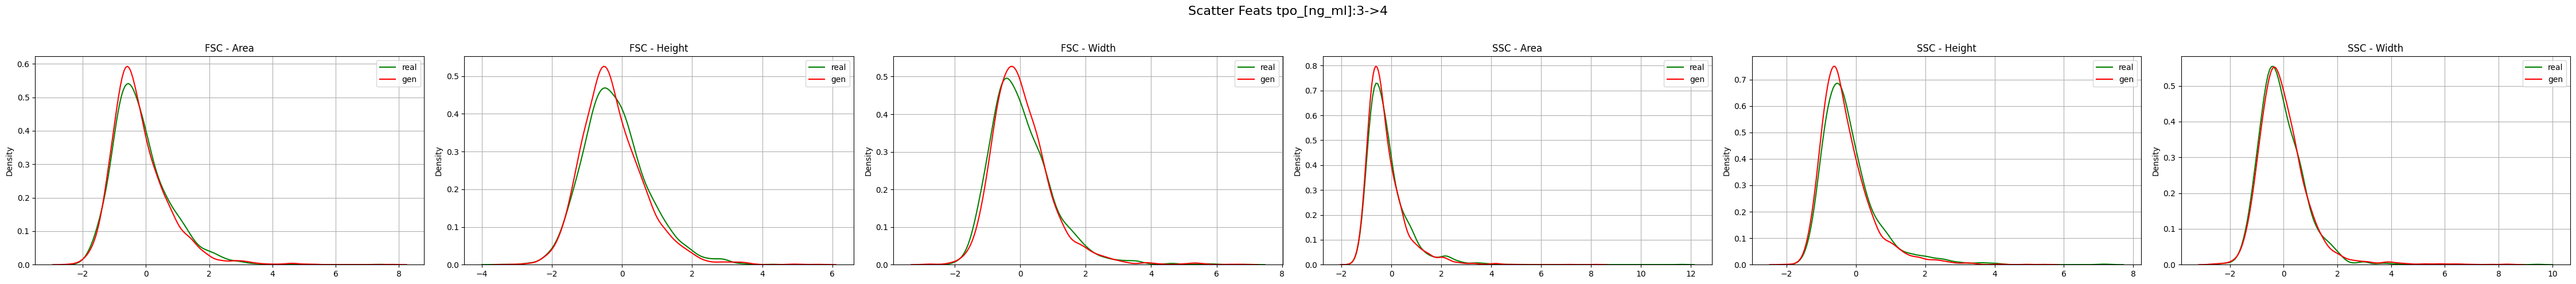

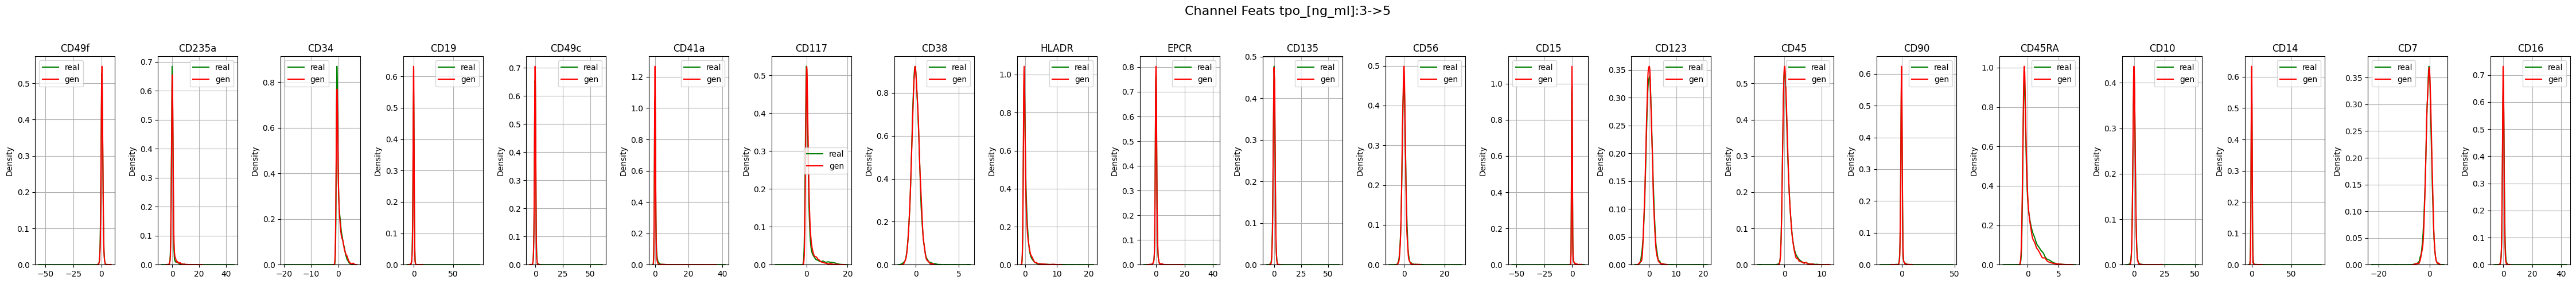

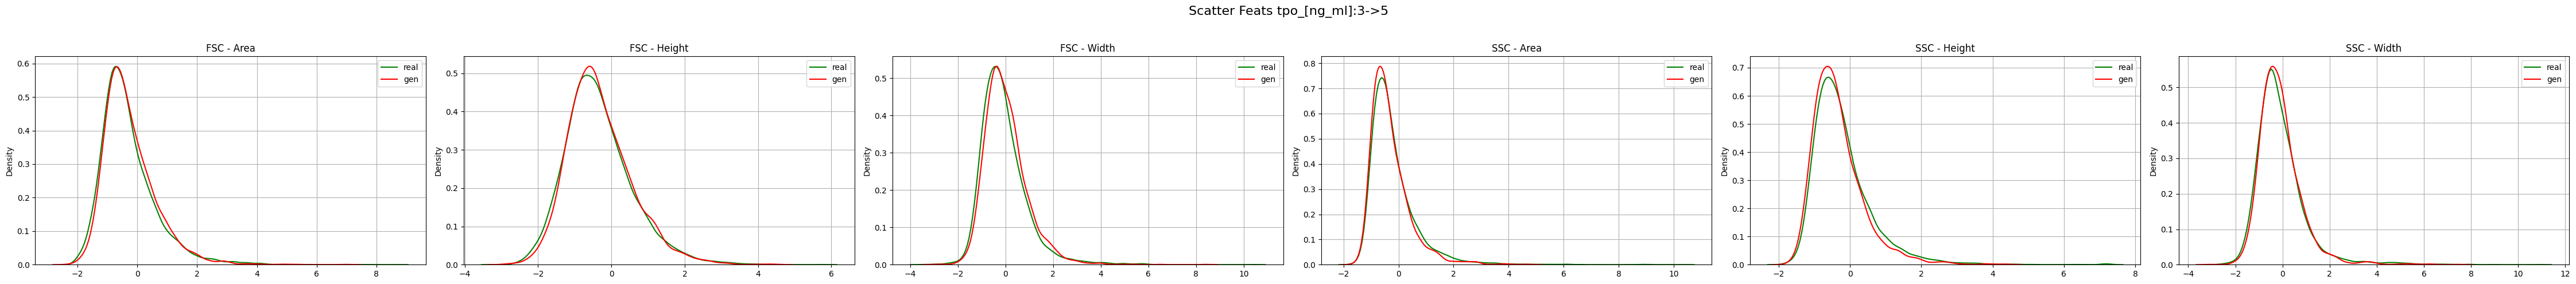

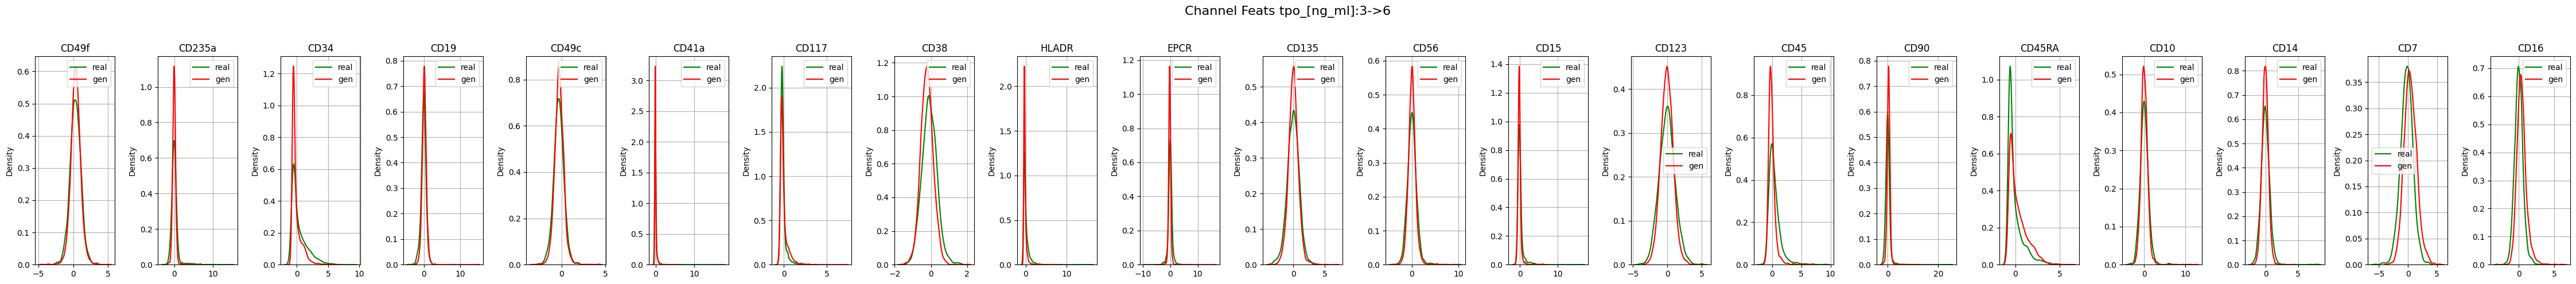

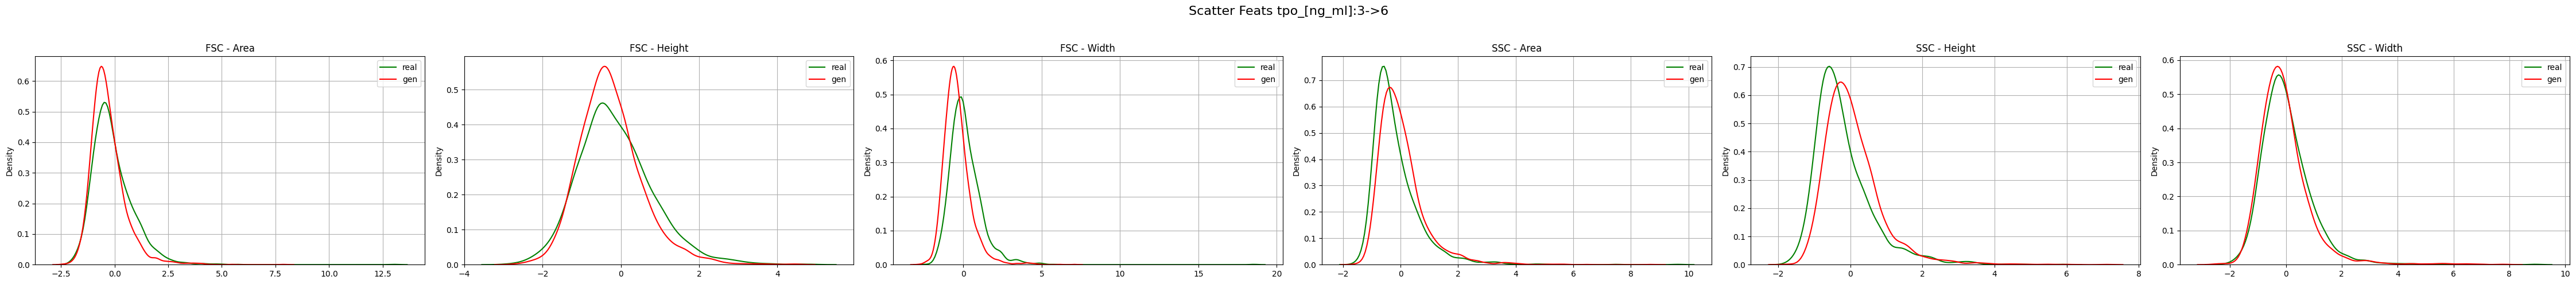

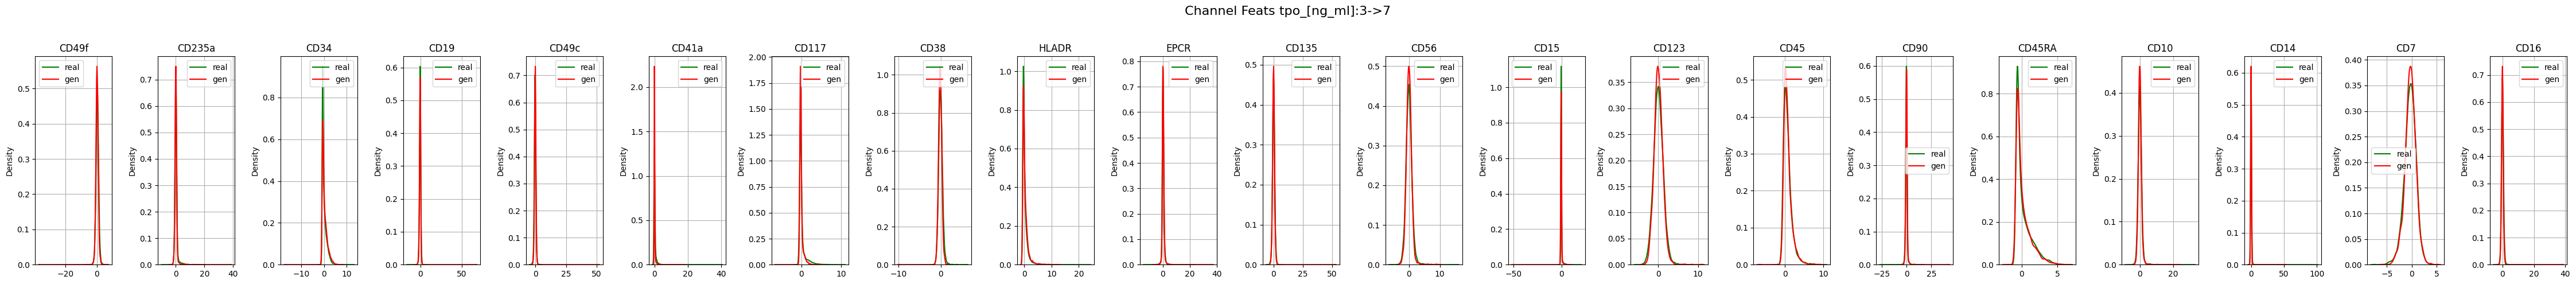

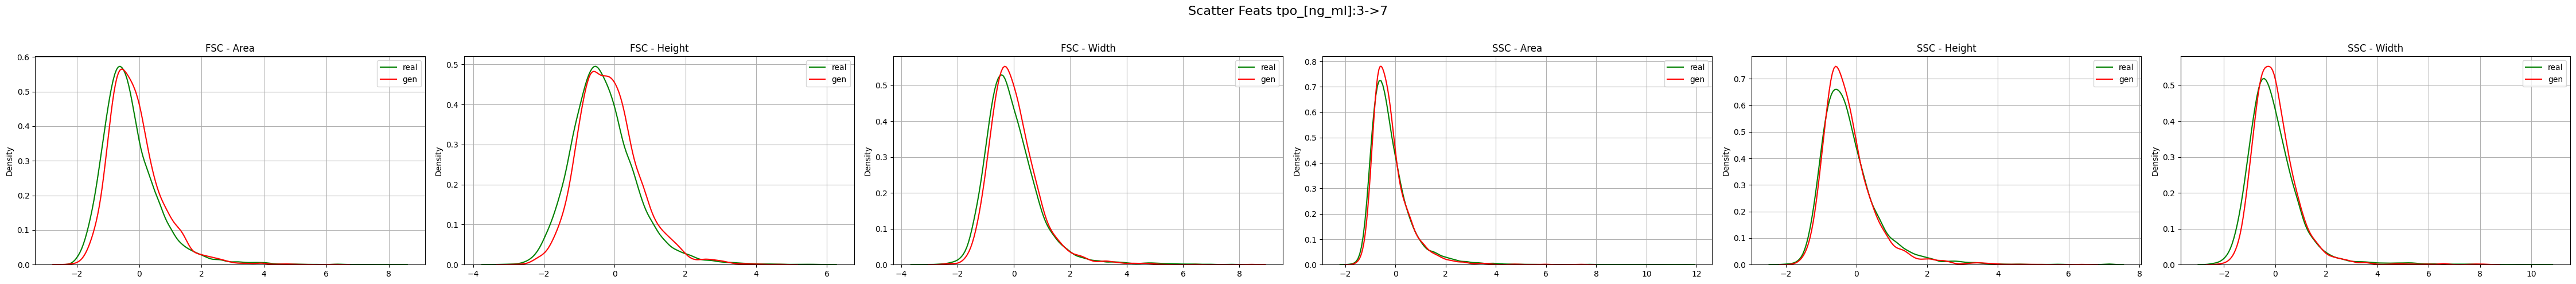

In [22]:
var_names = next(iter(ood2adatas.values()))["train"].var_names
for group_id, pred_adata_group in ood2adatas_concat.items():
    for cond_id, pred_adata in pred_adata_group.items():
        gt_adata = pred_adata[pred_adata.obs.is_true_cond]
        pd_adata = pred_adata[pred_adata.obs.is_generated]
        plot_marginals(gt_adata.X, X_gen=pd_adata.X, col_names=var_names, title=f"Channel Feats {group_id[0]}:{group_id[1]}->{cond_id}")
        plot_marginals(gt_adata.obsm["X_scatter"], X_gen=pd_adata.obsm["X_scatter"], col_names=scatter_columns, title=f"Scatter Feats {group_id[0]}:{group_id[1]}->{cond_id}")


## Clustering Analysis.

### Computing E-distance between each protocol.

In [20]:
compute_dists = True
if compute_dists:
    ood2edists = {}
    key_added = "e_distances"
    for idxo, (group_id, pred_adata_group) in enumerate(ood2adatas_concat.items()):
        group_e_dists = {}
        for idxi, (cond_id, pred_adata) in enumerate(pred_adata_group.items()):
            # grouping data by protocol id
            groups = pred_adata.obs.groupby(by=[perturbation_obs_key, "is_generated"]).groups

            # computing distances channel feats and storing results
            print(f"{group_id}:{cond_id} ({idxo}/{len(ood2adatas_concat)}:{idxi}/{len(pred_adata_group)} -> e-dists channel feats)")
            edists_channel = compute_distance_fn(pred_adata, groups)
            kchannel = f"X_channel_{key_added}_{perturbation_obs_key}"
            print(f"Writing results to `.uns` at {kchannel}")
            pred_adata.uns[kchannel] = edists_channel

            # computing distances channel feats and storing results
            print(f"{group_id}:{cond_id} ({idxo}/{len(ood2adatas_concat)}:{idxi}/{len(pred_adata_group)} -> e-dists scatter feats)")
            edists_scatter = compute_distance_fn(pred_adata, groups, state_repr="X_scatter")
            kscatter = f"X_scatter_{key_added}_{perturbation_obs_key}"
            print(f"Writing results to `.uns` at {kscatter}")
            pred_adata.uns[kscatter] = edists_scatter
            
            # storing to dict
            group_e_dists[cond_id] = {
                kchannel: edists_channel,
                kscatter: edists_scatter,
            }
        ood2edists[group_id] = group_e_dists


('tpo_[ng_ml]', 3):0 (0/1:0/8 -> e-dists channel feats)


Computing Distances (10, False):43:(10/117) <-> (62, False):1322:(63/117): : 1167it [00:23, 66.61it/s]                     

Computing Distances (114, False):154:(115/117) <-> (115, False):189:(116/117): : 6786it [04:49, 23.48it/s] 


Writing results to `.uns` at X_channel_e_distances_protocol_id
('tpo_[ng_ml]', 3):0 (0/1:0/8 -> e-dists scatter feats)


Computing Distances (114, False):154:(115/117) <-> (115, False):189:(116/117): : 6786it [02:50, 39.80it/s]                 


...

Writing results to `.uns` at X_scatter_e_distances_protocol_id
('tpo_[ng_ml]', 3):7 (0/1:7/8 -> e-dists channel feats)


Computing Distances (114, False):154:(115/117) <-> (115, False):189:(116/117): : 6786it [04:49, 23.47it/s]                 


Writing results to `.uns` at X_channel_e_distances_protocol_id
('tpo_[ng_ml]', 3):7 (0/1:7/8 -> e-dists scatter feats)


Computing Distances (114, False):154:(115/117) <-> (115, False):189:(116/117): : 6786it [02:52, 39.30it/s]                 

Writing results to `.uns` at X_scatter_e_distances_protocol_id


### Saving the computed distances to disk.

In [21]:
store_results = True
if store_results:
    assert compute_dists
    for k, v in ood2edists.items():
        # creating dictionary for run results
        run_name = tgt_res_df.loc[k].run_name
        run_dict = {
            "split": "|".join([str(_) for _ in k]),
            "distances": v,
        }
        # creating directory for current run
        run_dir = os.path.join(DISTS_DUMP_DIR, run_name)
        if not os.path.exists(run_dir):
            os.mkdir(run_dir)
        n_results = len(os.listdir(run_dir))
        # results path
        res_path = os.path.join(run_dir, f"{n_results}_distances.yaml")
        # dumping results
        with open(res_path, "w") as fb:
            yaml.dump(run_dict, fb)


### Displaying the distances.

In [23]:
ood2edists

{('tpo_[ng_ml]',
  3): {0: {'X_channel_e_distances_protocol_id': {'(0, False)|(1, False)': 9.332977460571271,
    '(0, False)|(2, False)': 10.714637772934344,
    '(0, False)|(3, False)': 5.307283400057976,
    '(0, False)|(4, False)': 24.152168159844592,
    '(0, False)|(5, False)': 33.62962087720064,
    '(0, False)|(6, False)': 3.6358826327064193,
    '(0, False)|(7, False)': 7.394609733256026,
    '(0, False)|(8, False)': 7.382008236152409,
    '(0, False)|(9, False)': 3.4943990383916486,
    '(0, False)|(10, False)': 1.8432153736560721,
    '(0, False)|(11, False)': 1.6500978978178864,
    '(0, False)|(12, False)': 2.4632938165444713,
    '(0, False)|(13, False)': 16.80850402828132,
    '(0, False)|(14, False)': 27.310352336284474,
    '(0, False)|(15, False)': 18.136408695227008,
    '(0, False)|(16, False)': 27.437889058685872,
    '(0, False)|(17, False)': 10.94288989930152,
    '(0, False)|(18, False)': 25.834813564730215,
    '(0, False)|(19, False)': 19.209440669881637,
    